In [92]:
import os
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import sys
sys.path.append('/nird/projects/NS9873K/emile/unseen-storm-forecasts')

import xarray as xr
import numpy as np

In [93]:
import test_fidelity as fid
import test_independence as ind
import test_stability as stab

Checking raw data tests

In [94]:
processed = xr.open_dataarray("processed-october.nc")
maxs = xr.open_dataarray("maxs-october.nc")

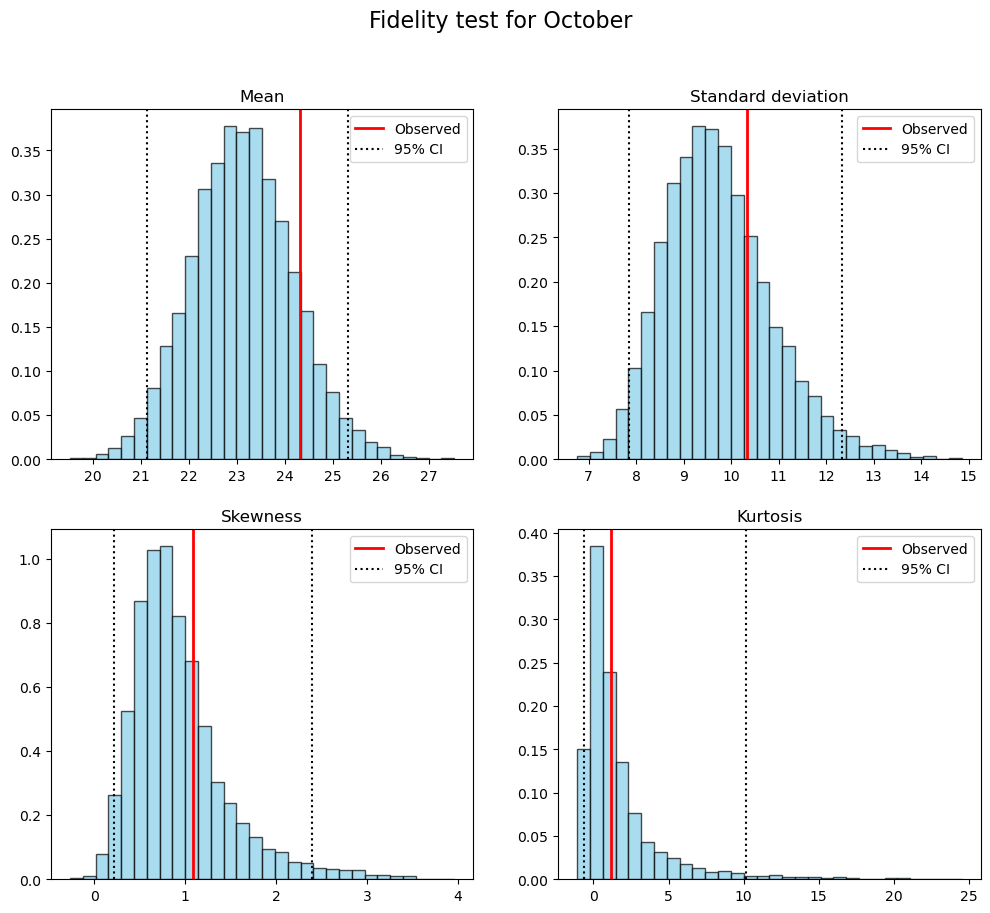

In [95]:
rea, mod = fid.main("maxs-october.nc", "../../data/processed-rea.nc")
fid.plot(rea, mod, "raw", "October", show=True)

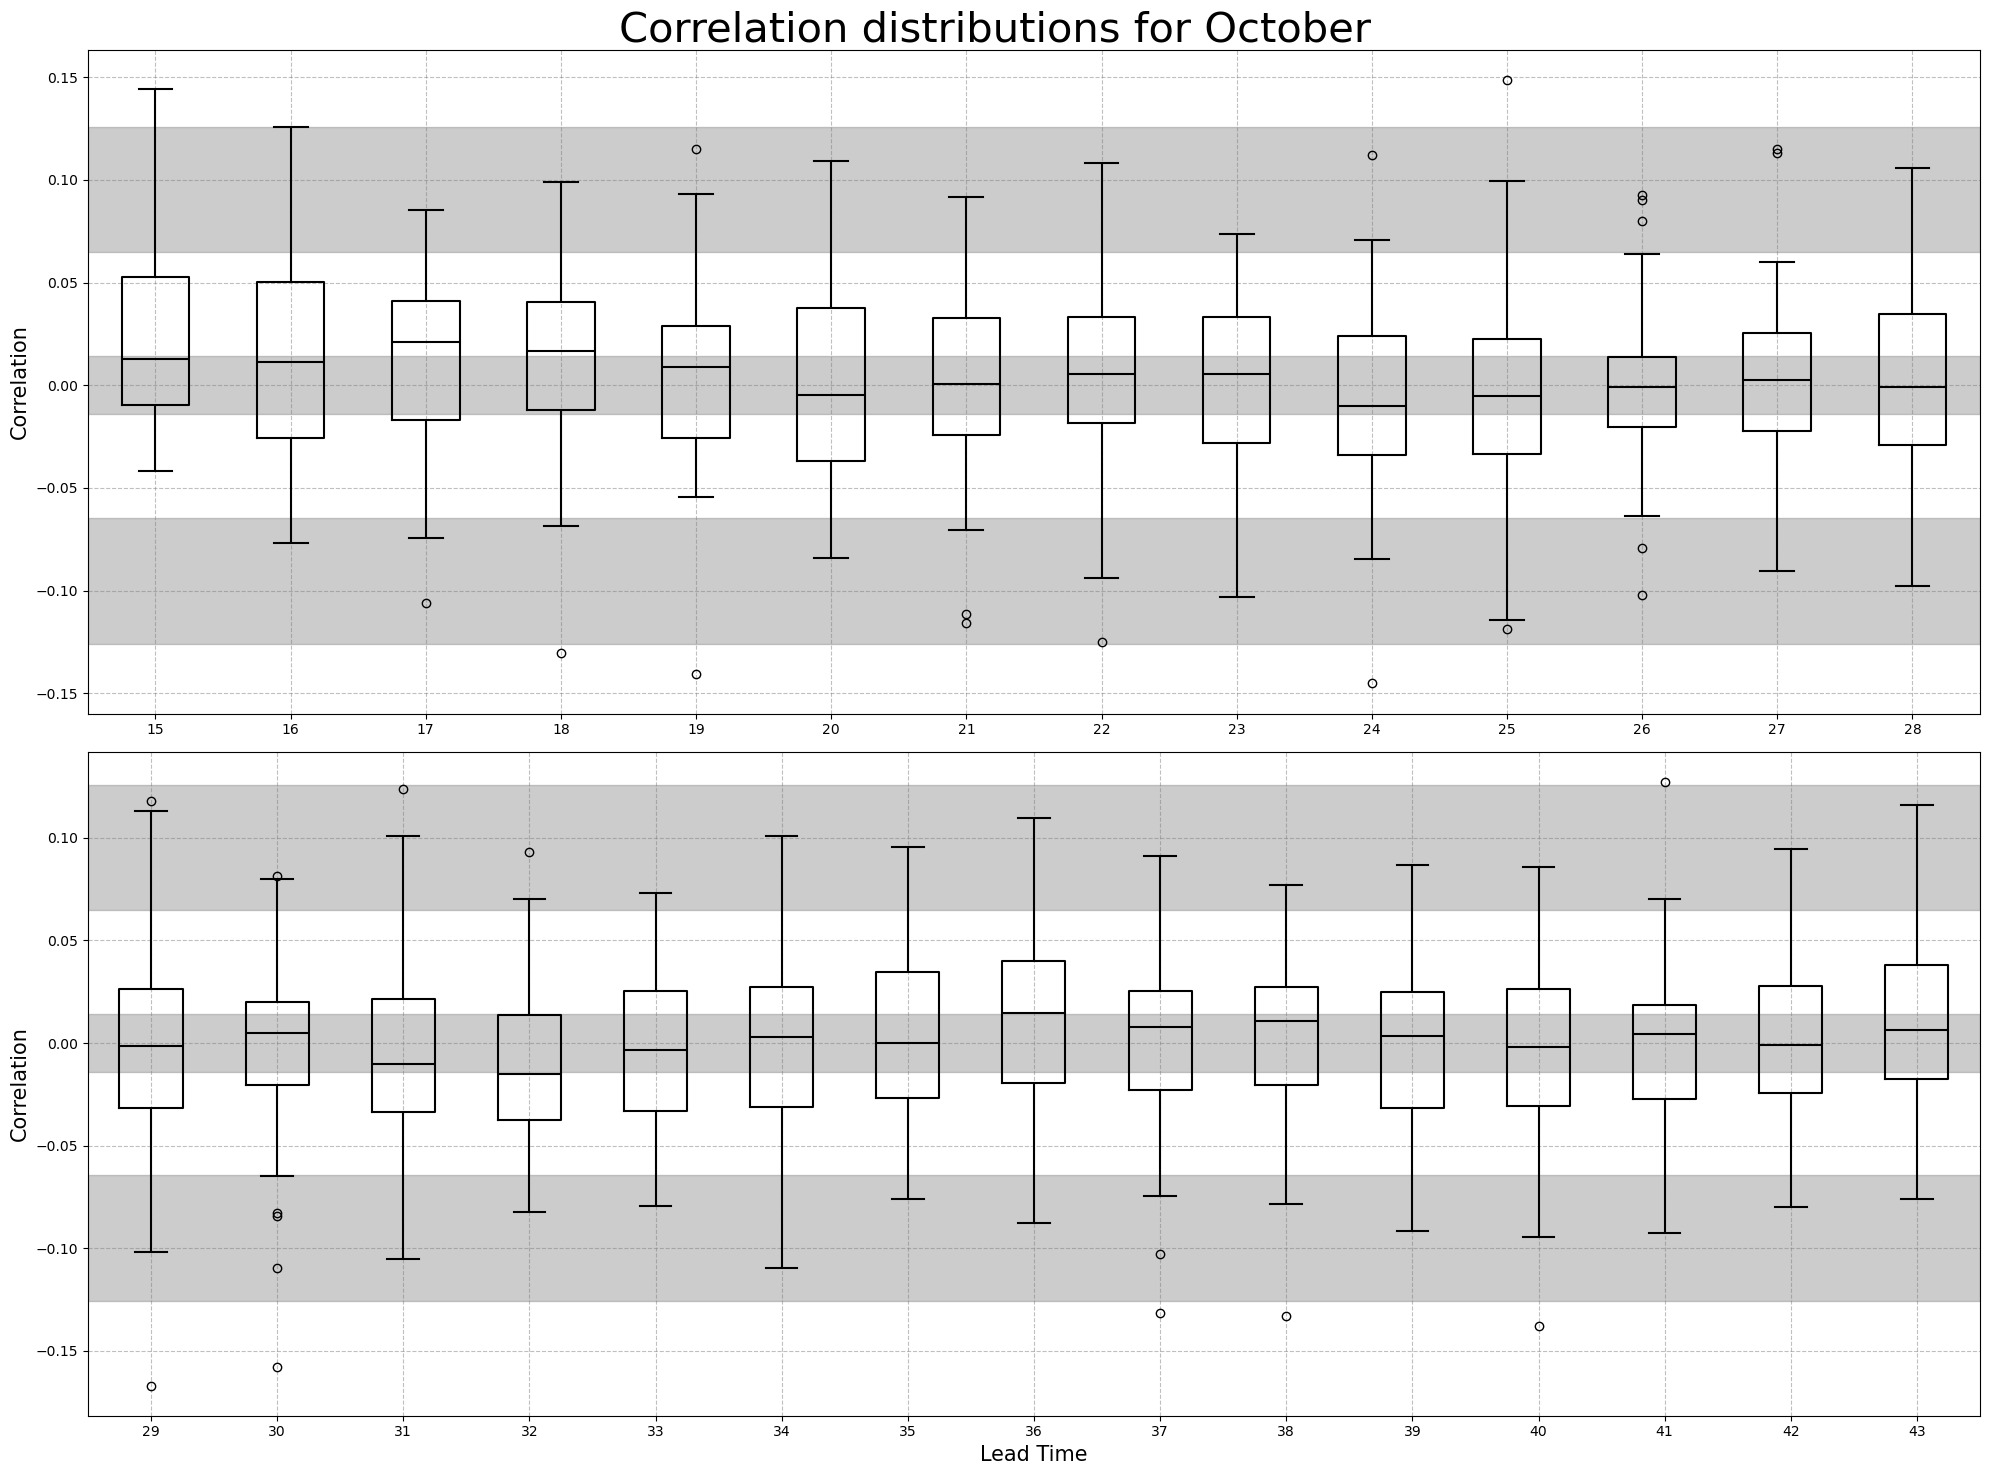

In [96]:
corr, interv = ind.correlation(processed)
ind.plot_correlations(corr, interv, "raw",show=True)

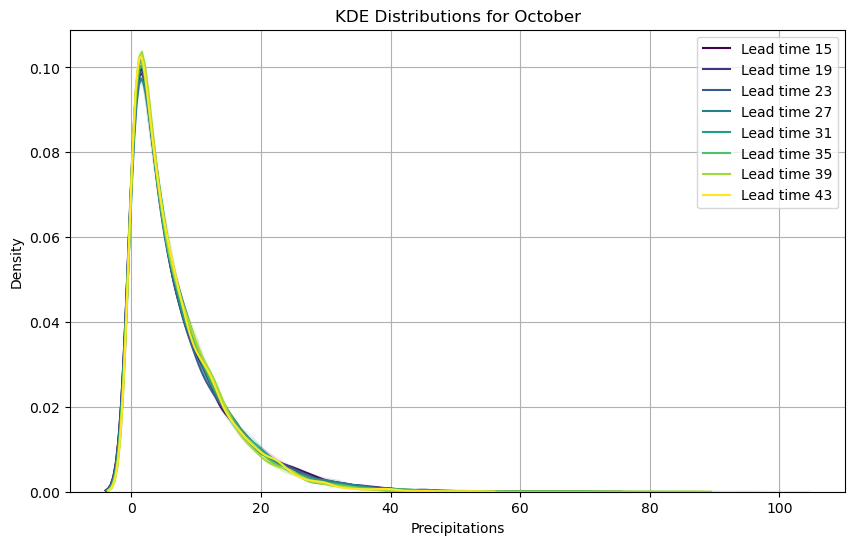

In [97]:
stab.plot_kde_distributions(processed, "raw", show=True)

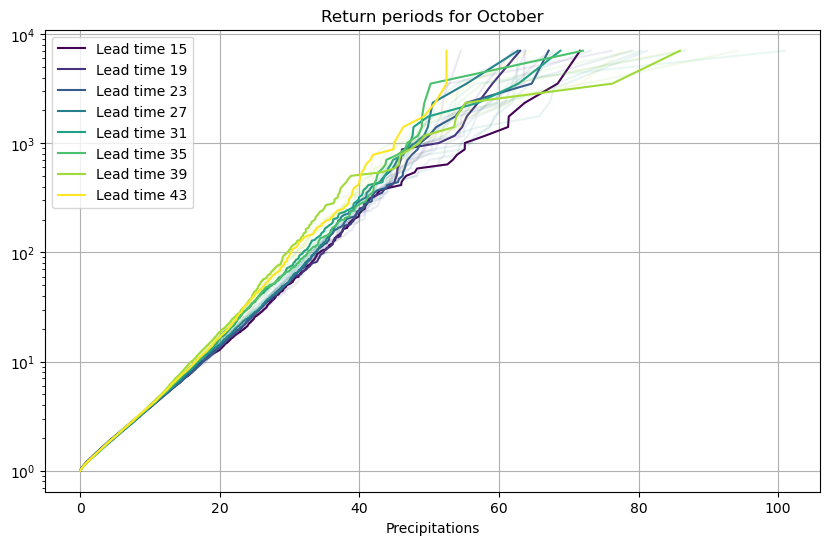

In [98]:
stab.plot_return_period(processed, "raw", show=True)

### Correcting stability

In [99]:
stacked = processed.copy().stack(
    d=["date", "number"]
).reset_index('d').drop_vars(
    ["date", "number", "month"]
)
vals = stacked.values

In [100]:
vals = vals[:,~np.isnan(vals[0])]

vals_sorted = np.sort(vals, axis=1)
refs = np.sort(vals[0], axis=-1)
vals_diffs = (vals_sorted - refs)

diffs = xr.DataArray(
    data = np.array([vals_sorted, vals_diffs]),
    dims = ("var",) + stacked.dims,
    coords = dict(
        var = ["val", "diff"],
        time = stacked.time
    )
)
diffs.to_netcdf("diffs.nc")

In [101]:
def grad(X, y, theta):
    n = X.shape[0]
    return 2 / n * X.T.dot(X.dot(theta) - y)

def gd(X, y, step, nb):
    
    cost_history = []
    
    m = len(X)
    X = np.c_[np.ones((m,1)), X]
    if len(y.shape)==1:
        y = y.reshape((len(y),1))
    
    theta = np.zeros((3,1))
    
    for i in range(nb):
        theta -= step*grad(X, y, theta)
        if (np.any(np.isnan(theta)) or np.any(np.isinf(theta))): 
            print("Nan or Inf value in theta")
            return [0,0], []
        
        if i%10 == 0:
            risk = np.nanmean((X.dot(theta)-y)**2)
            cost_history.append(risk)
    
    return theta, cost_history

In [102]:
corrected_2 = processed.copy()
stored_costs = []
for tid, t in enumerate(corrected_2.time.values):
    y = diffs.sel(var="diff", time=t).values
    x = np.zeros((len(y), 2))
    x[:, 0] = diffs.sel(var="val", time=t).values
    x[:, 1] = diffs.sel(var="val", time=t).values**2
    
    theta, costs = gd(x, y, 1e-6, 2000)
    stored_costs.append(costs)
    
    vals = corrected_2.sel(time=t).values
    corrected_2[...,tid] -= theta[0] + theta[1]*vals + theta[2]*vals**2

In [103]:
import matplotlib.pyplot as plt

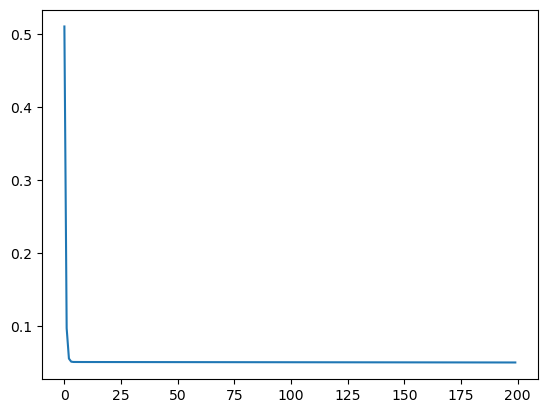

In [104]:
plt.plot(stored_costs[-2])
plt.show()

In [105]:
corrected_2.to_netcdf("corrected_2.nc")
maxs_corrected_2 = corrected_2.max(dim="time")
maxs_corrected_2.to_netcdf("maxs_corrected_2.nc")

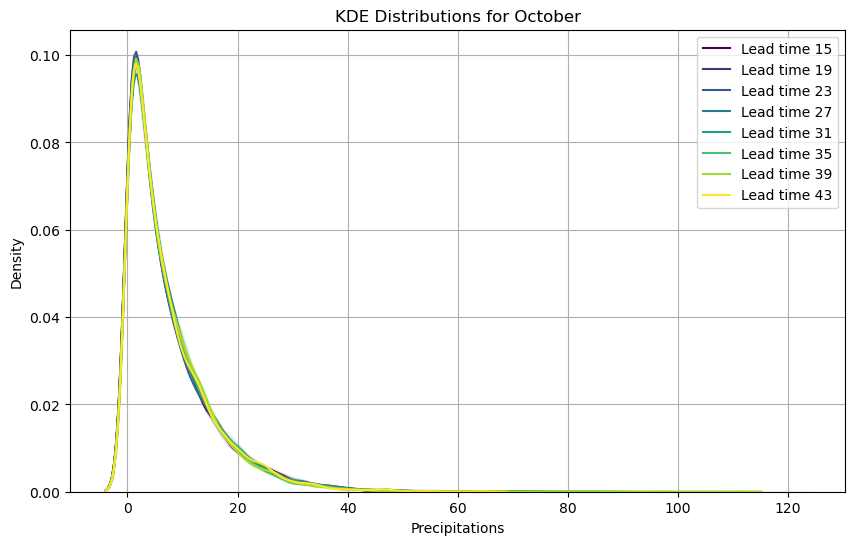

In [106]:
stab.plot_kde_distributions(corrected_2, "", show=True)

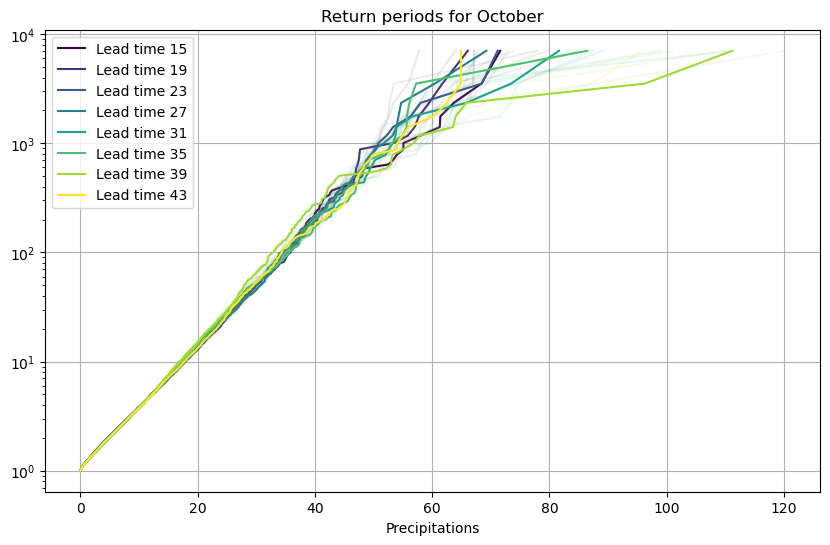

In [107]:
stab.plot_return_period(corrected_2, "", show=True)

### Final test

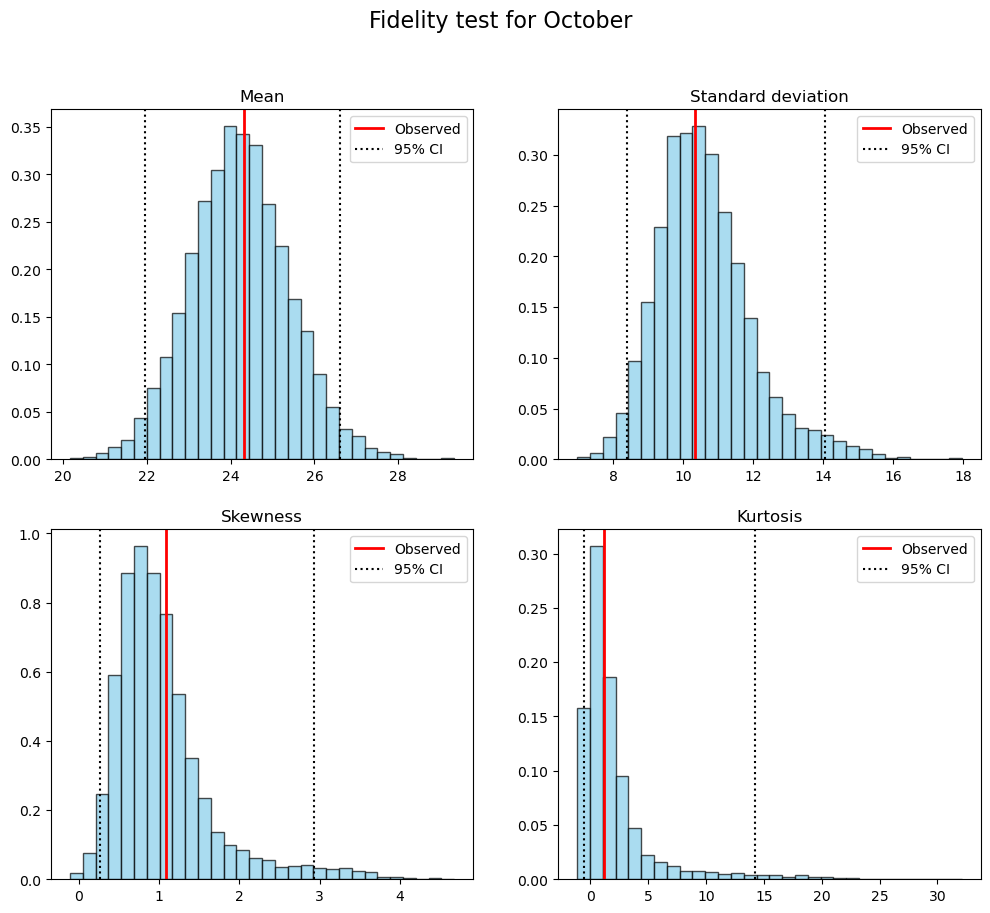

In [108]:
rea, mod = fid.main(
    "maxs_corrected_2.nc", "../../data/processed-rea.nc"
)
fid.plot(rea, mod, "", "October", show=True)

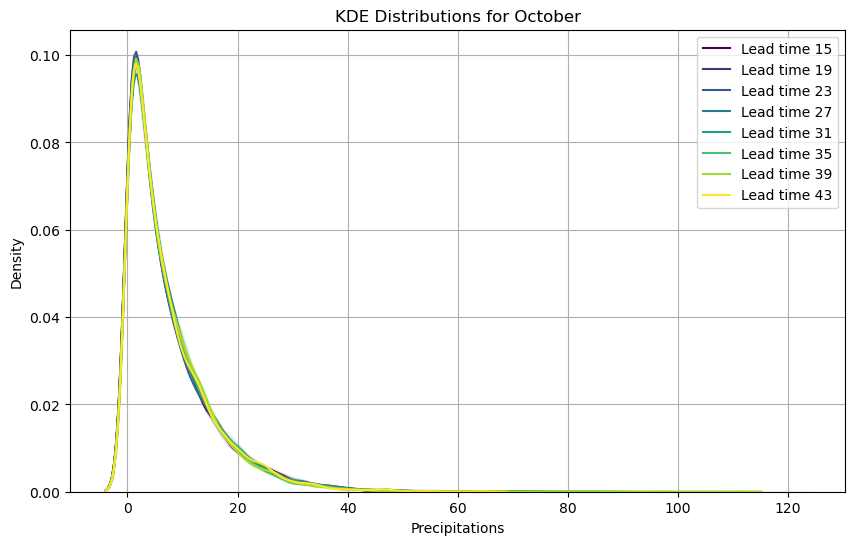

In [109]:
stab.plot_kde_distributions(
    corrected_2, "", show=True
)

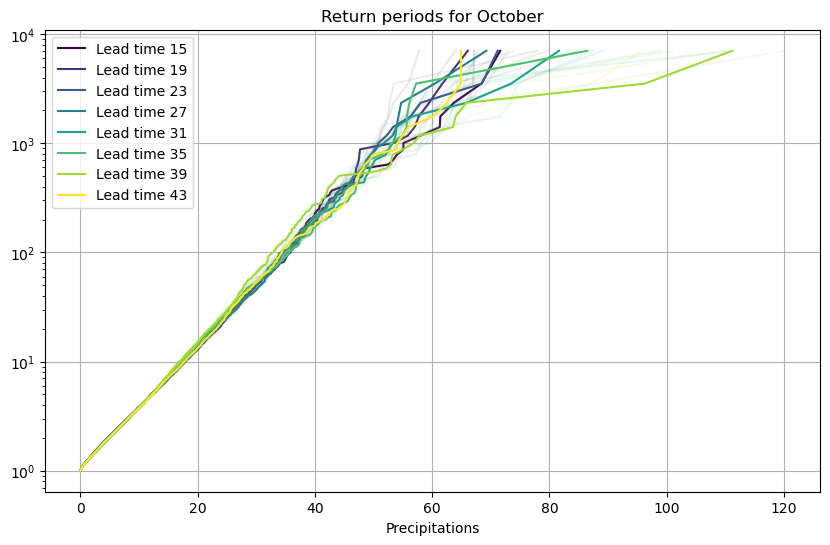

In [110]:
stab.plot_return_period(
    corrected_2, "", show=True
)

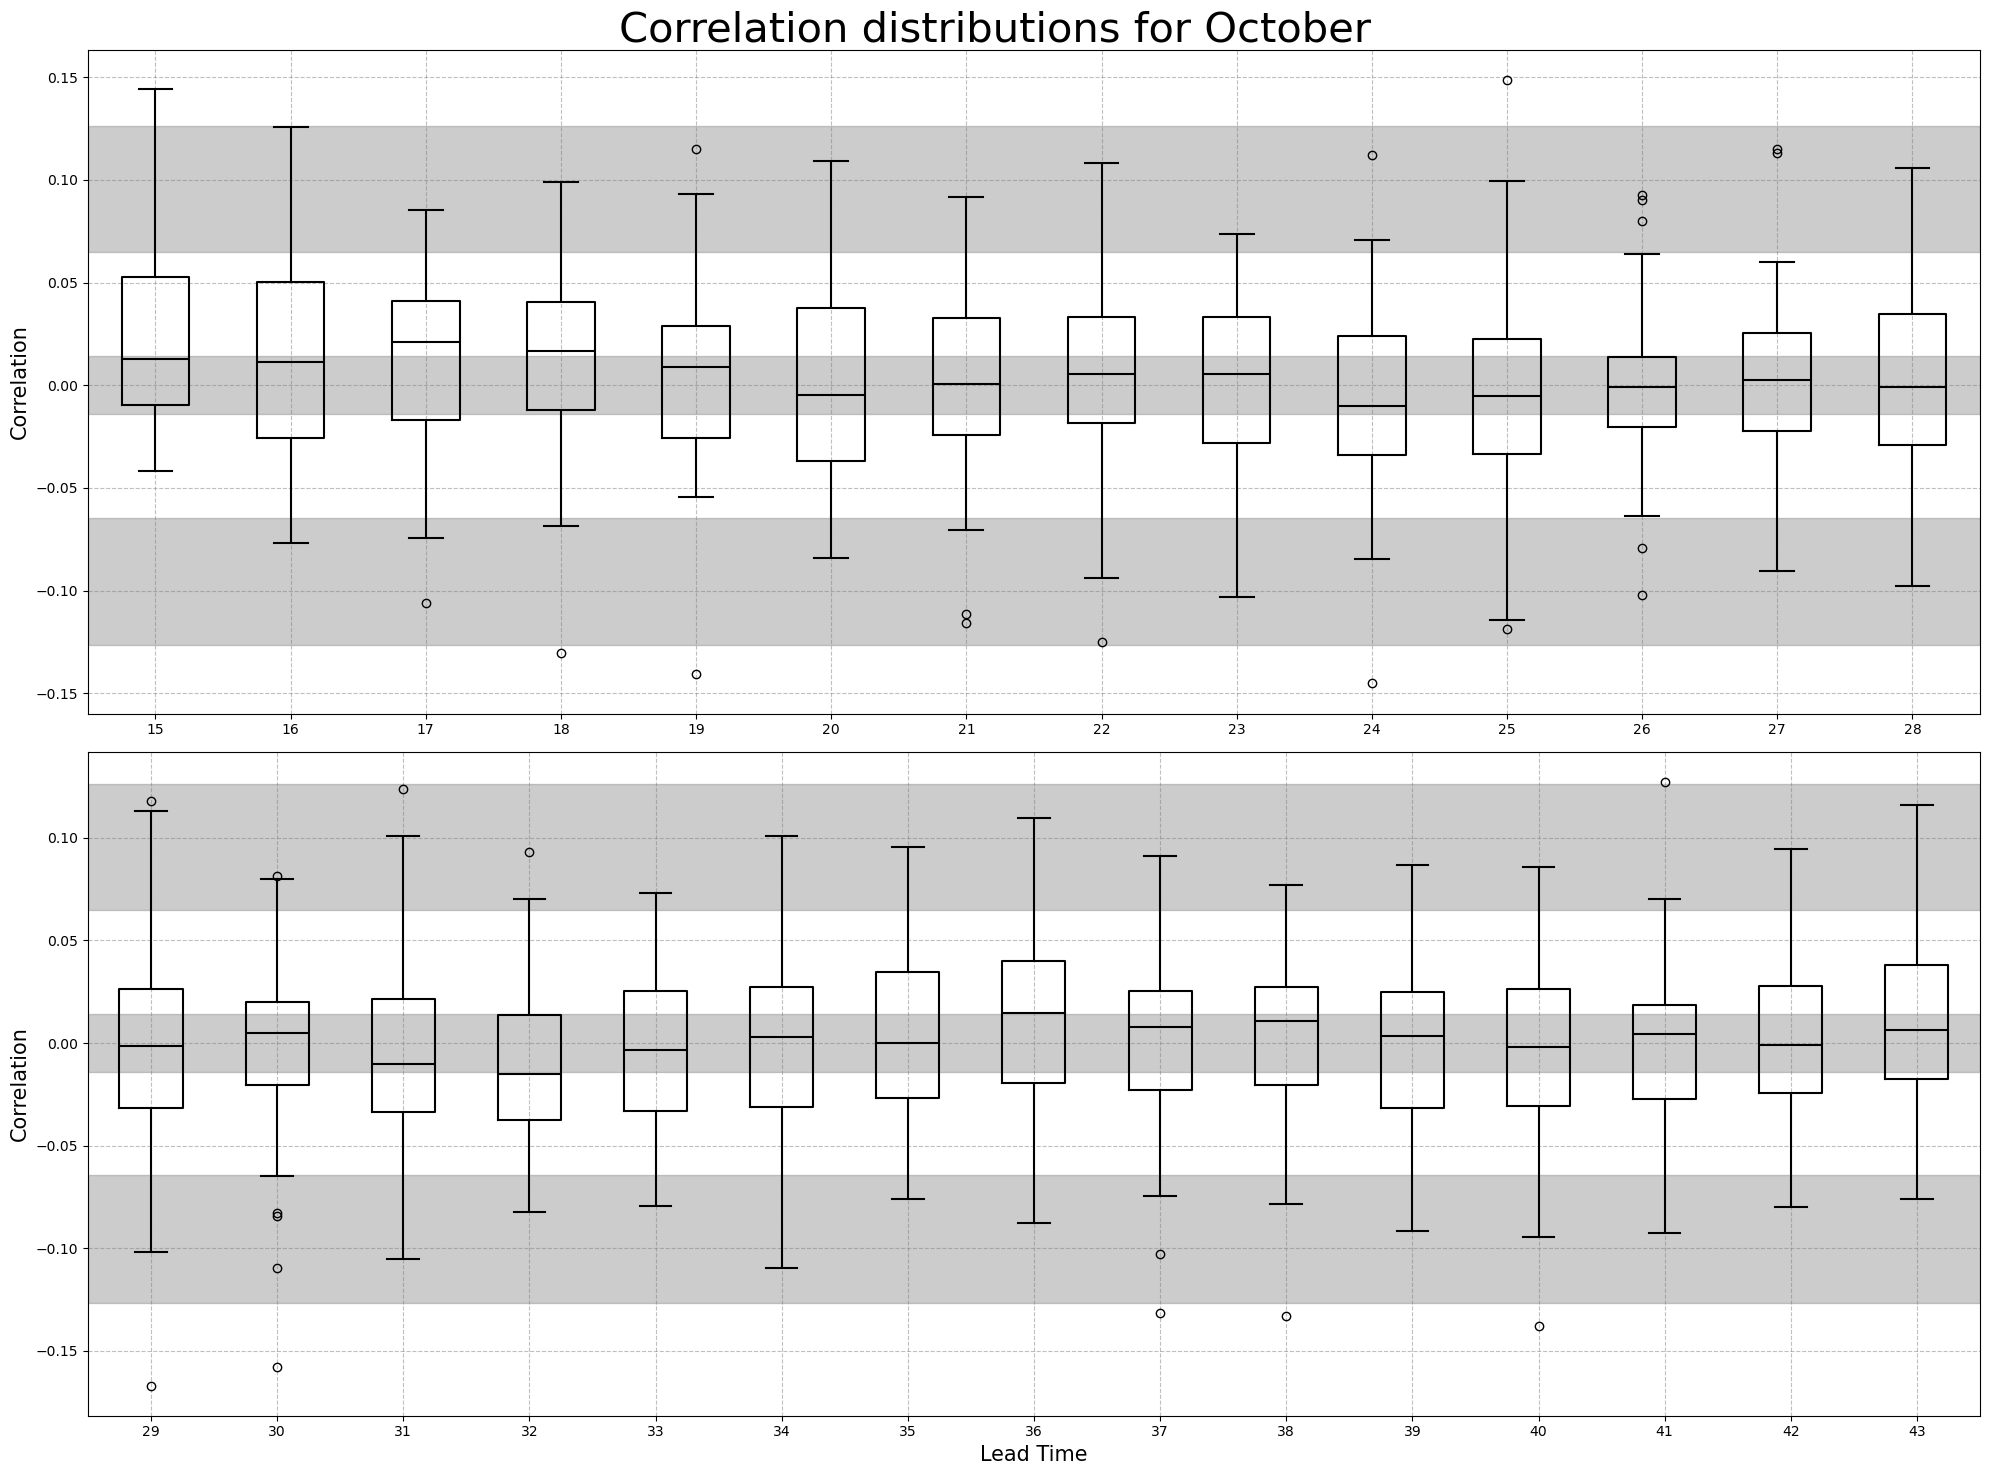

In [111]:
corr, interv = ind.correlation(corrected_2)
ind.plot_correlations(corr, interv, "", show=True)